<h2>PreProcessing</h2>

In [1]:
%matplotlib ipympl

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import Fido, attrs as a
from astropy import units as u
from astropy.coordinates import SkyCoord
import sunpy_soar
from glob import glob
from IPython.display import HTML
from astropy.io import fits
from astropy.time import Time
from datetime import datetime
from pastamarkers import pasta, salsa
from stixpy.product import Product
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

In [3]:
plt.close('all')

<h3>Crop maps from images</h3>

In [4]:
short_exposure_images = glob(r'C:\python_code\hrishort\*.fits')

In [5]:
# initial_map = sunpy.map.Map(short_exposure_images[0])

In [6]:
#initial_map.quicklook()

In [7]:
# tr_x=3200
# tr_y=-550
# bl_x=3000
# bl_y=-800

In [8]:
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=initial_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=initial_map.coordinate_frame)
# short_exposure_map_seq = initial_map.submap(bottom_left=bottom_left, top_right=top_right)
# #short_exposure_map_seq.quicklook()

In [9]:
# second_map = sunpy.map.Map(short_exposure_images[1])
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=second_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=second_map.coordinate_frame)
# second_map_crop = second_map.submap(bottom_left=bottom_left, top_right=top_right)
# short_exposure_map_seq = sunpy.map.Map([short_exposure_map_seq, second_map_crop], sequence = True)
# third_map = sunpy.map.Map(short_exposure_images[2])
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=third_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=third_map.coordinate_frame)
# third_map_crop = third_map.submap(bottom_left=bottom_left, top_right=top_right)
# short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [third_map_crop], sequence = True)

In [10]:
# for i in range(1346):
#     next_map = sunpy.map.Map(short_exposure_images[3+i])
#     top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=next_map.coordinate_frame)
#     bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=next_map.coordinate_frame)
#     next_map_crop = next_map.submap(bottom_left=bottom_left, top_right=top_right)
#     short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [next_map_crop], sequence = True)

<h3>Load in pre-cropped maps</h3>

In [11]:
index = 0
file_name = r'C:\Users\RH\miniforge3\Scripts\unmasked_map_seq\unmasked_map_'

In [12]:
initial_map = sunpy.map.Map(file_name + str(0) + '.fits')
second_map = sunpy.map.Map(file_name + str(1) + '.fits')
unmasked_map_seq = sunpy.map.Map(initial_map, [second_map], sequence = True)
for index in range(1346):
    n = str(index+2)
    filename = file_name + str(index) + '.fits'
    recall_map = sunpy.map.Map(filename)
    unmasked_map_seq = sunpy.map.Map(unmasked_map_seq.maps + [recall_map], sequence = True)

In [13]:
short_exposure_map_seq = unmasked_map_seq

<h2>Apply thresholding</h2>

In [24]:
max = np.zeros(1348)
for i in range(1348):
    max[i] = (short_exposure_map_seq[i]).max()

In [15]:
# max.max()

In [16]:
# threshold = 0.5*max.max()
# bright_pixels_50 = np.zeros(1348)
# for k in range(1348):
#     #determine the map size
#     xdim = int(short_exposure_map_seq[k].dimensions[0].value)
#     ydim = int(short_exposure_map_seq[k].dimensions[1].value)
    
#     for i in range(ydim-1):
#         for j in range(xdim-1):
#             current_map = short_exposure_map_seq[k]
#             if current_map.data[i,j] >= threshold:
#                 bright_pixels_50[k] = bright_pixels_50[k] + 1

In [17]:
#np.savetxt(r'C:\python_code\hrishort\bright_pixels_50.txt', bright_pixels_50)

<h3>Load thresholded arrays and create time array</h3>

These arrays hold the number of pixels left unmasked at each threshold

In [18]:
bright_pixels_3 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_3.txt')
bright_pixels_5 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_5.txt')
bright_pixels_10 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_10.txt')
bright_pixels_20 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_20.txt')
bright_pixels_30 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_30.txt')
bright_pixels_50 = np.loadtxt(r'C:\python_code\hrishort\bright_pixels_50.txt')

In [19]:
euitimes = []
for i in range(1348):
    hdul = fits.open(short_exposure_images[i])
    hdu1 = hdul[1]
    euitimes.append(hdu1.header["DATE-BEG"])
    hdul.close()

In [20]:
euitimes = Time(euitimes)

<h3>Plot number of unmasked pixels over time</h3>

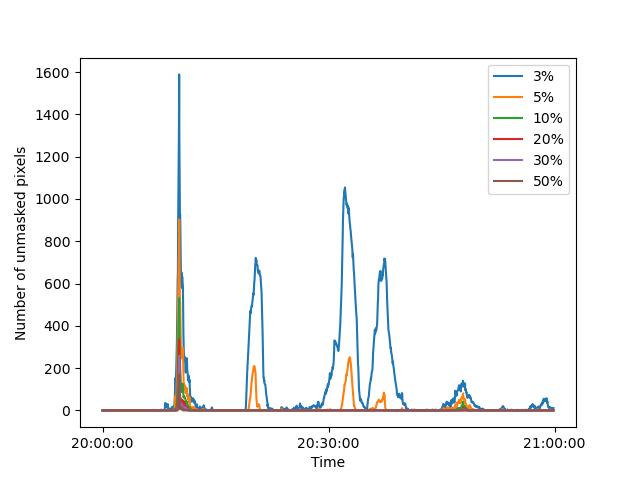

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(euitimes.to_datetime(), bright_pixels_3, label = "3%")
ax.plot(euitimes.to_datetime(), bright_pixels_5, label = "5%")
ax.plot(euitimes.to_datetime(), bright_pixels_10, label = "10%")
ax.plot(euitimes.to_datetime(), bright_pixels_20, label = "20%")
ax.plot(euitimes.to_datetime(), bright_pixels_30, label = "30%")
ax.plot(euitimes.to_datetime(), bright_pixels_50, label = "50%")
ax.set_xticks([datetime(2024,4,5,20,0,0,0), datetime(2024,4,5,20,30,0,0), datetime(2024,4,5,21,0,0,0)],['20:00:00', '20:30:00', '21:00:00'])
ax.set_xlabel("Time")
ax.set_ylabel("Number of unmasked pixels")
ax.legend()
plt.show()

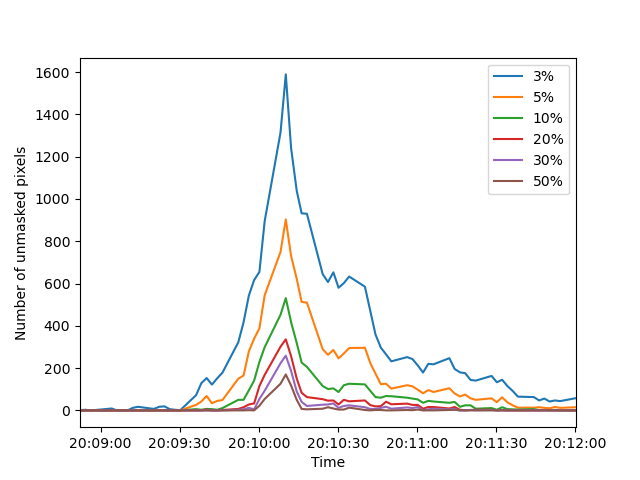

In [22]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(euitimes.to_datetime(), bright_pixels_3, label = "3%")
ax2.plot(euitimes.to_datetime(), bright_pixels_5, label = "5%")
ax2.plot(euitimes.to_datetime(), bright_pixels_10, label = "10%")
ax2.plot(euitimes.to_datetime(), bright_pixels_20, label = "20%")
ax2.plot(euitimes.to_datetime(), bright_pixels_30, label = "30%")
ax2.plot(euitimes.to_datetime(), bright_pixels_50, label = "50%")
ax2.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
ax2.set_xlabel("Time")
ax2.set_ylabel("Number of unmasked pixels")
ax2.legend()
plt.show()

<h2>Apply 5% mask to maps</h2>

In [26]:
threshold = 0.05*max.max()
initial_masked_5 = short_exposure_map_seq[0]
xdim = int(initial_masked_5.dimensions[0].value)
ydim = int(initial_masked_5.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if initial_masked_5.data[i,j] < threshold:
            initial_masked_5.data[i,j] = 0

In [27]:
second_masked_5 = short_exposure_map_seq[1]
xdim = int(second_masked_5.dimensions[0].value)
ydim = int(second_masked_5.dimensions[1].value)
for i in range(ydim):
    for j in range(xdim):
        if second_masked_5.data[i,j] < threshold:
            second_masked_5.data[i,j] = 0

In [28]:
masked_map_seq_5 = sunpy.map.Map([initial_masked_5, second_masked_5], sequence = True)

In [29]:
for n in range(1346):
    next_map = short_exposure_map_seq[2+n]
    xdim = int(next_map.dimensions[0].value)
    ydim = int(next_map.dimensions[1].value)
    for i in range(ydim):
        for j in range(xdim):
            if next_map.data[i,j] < threshold:
                next_map.data[i,j] = 0
    masked_map_seq_5 = sunpy.map.Map(masked_map_seq_5.maps + [next_map], sequence = True)

<h3>Plot total emission from unmasked pixels over time</h3>

In [30]:
intensity = np.zeros(1348)
for n in range(1348):
    intensity[n] = np.sum(masked_map_seq_5[n].data)

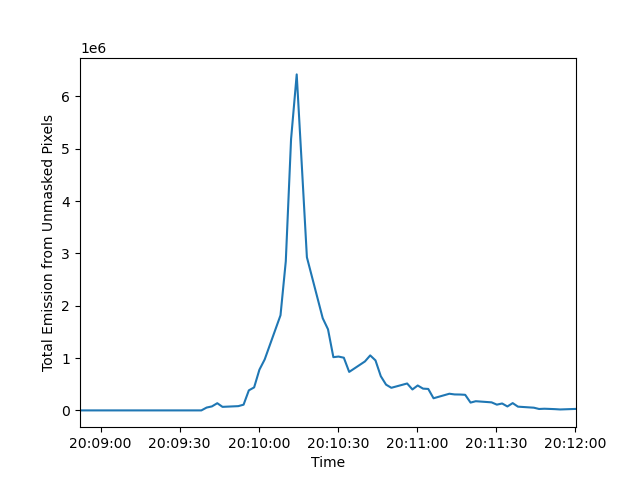

In [31]:
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(euitimes.to_datetime(), intensity)
ax3.set_xlabel("Time")
ax3.set_ylabel("Total Emission from Unmasked Pixels")
ax3.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

<h2>Apply watershed segmentation</h2>

<h3>Visualise segmentation</h3>

In [32]:
kernel_sizes = np.zeros(200)

In [33]:
index = 228

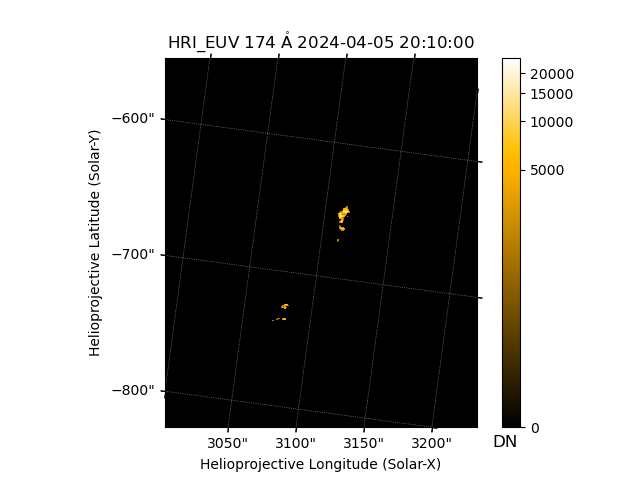

In [34]:
short_exposure_map_seq[index].peek()

In [35]:
image = masked_map_seq_5[index].data

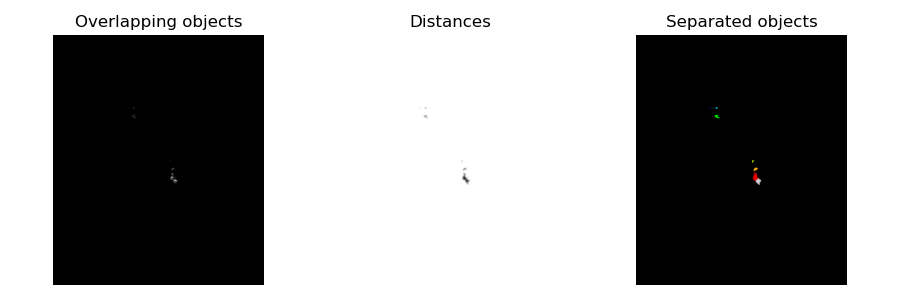

In [41]:
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, min_distance = 4, num_peaks_per_label = 1)#, labels = image)#, footprint=np.ones((3, 3)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

#labels = watershed(image)

fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

for a in ax:
    a.set_axis_off()

fig.tight_layout()
plt.show()

In [42]:
image_kernel_sizes = np.zeros(labels.max() - 1)
for i in range(labels.shape[0]-1):
    for j in range(labels.shape[1]-1):
        for k in range(labels.max()):
            if labels[i,j] == k+1:
                image_kernel_sizes[k-1] = image_kernel_sizes[k-1]+1

In [43]:
# fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
# ax = axes.ravel()

# ax[0].imshow(image, cmap=plt.cm.gray)
# ax[0].set_title('Overlapping objects')
# ax[1].imshow(-distance, cmap=plt.cm.gray)
# ax[1].set_title('Distances')
# ax[2].imshow(labels_temp, cmap=plt.cm.nipy_spectral)
# ax[2].set_title('Separated objects')

# for a in ax:
#     a.set_axis_off()

# fig.tight_layout()
# plt.show()

In [44]:
image_kernel_sizes = np.zeros(labels.max()-1)

for i in range(labels.shape[0] - 1):
    for j in range(labels.shape[1] - 1):
        for k in range(labels.max() - 1):
            if labels[i,j] == k+1:
                image_kernel_sizes[k] = image_kernel_sizes[k] + 1

In [45]:
image_kernel_sizes #array of the sizes of kernels identified on this image

array([  2.,   3.,  17.,   3.,  55.,  15.,  46., 139.])

In [46]:
image_kernel_sizes.shape[0] #number of kernels identified on this image

8

In [47]:
for i in range(image_kernel_sizes.shape[0]):
    size = (int(image_kernel_sizes[i]))
    kernel_sizes[size] = kernel_sizes[size] + 1

In [48]:
kernel_sizes = np.zeros(2000)

In [49]:
for n in range(65):
    index = 216 + n
    image = masked_map_seq_5[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)#, footprint=np.ones((3, 3)), labels=image)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    if labels.max() != 0:
        image_kernel_sizes = np.zeros(labels.max() - 1)
        for i in range(labels.shape[0]-1):
            for j in range(labels.shape[1]-1):
                for k in range(labels.max()-1):
                    if labels[i,j] == k+1:
                        image_kernel_sizes[k] = image_kernel_sizes[k]+1
        for m in range(image_kernel_sizes.shape[0]):
            size = (int(image_kernel_sizes[m]))
            if size > 60:
                print("at frame: ", n)
                print("there's a kernel of size: ", size)
            kernel_sizes[size] = kernel_sizes[size] + 1

at frame:  11
there's a kernel of size:  74
at frame:  12
there's a kernel of size:  139
at frame:  13
there's a kernel of size:  66
at frame:  13
there's a kernel of size:  64
at frame:  13
there's a kernel of size:  191
at frame:  15
there's a kernel of size:  63
at frame:  15
there's a kernel of size:  746
at frame:  16
there's a kernel of size:  67
at frame:  17
there's a kernel of size:  64
at frame:  18
there's a kernel of size:  170
at frame:  19
there's a kernel of size:  83
at frame:  20
there's a kernel of size:  88
at frame:  21
there's a kernel of size:  98
at frame:  22
there's a kernel of size:  74
at frame:  25
there's a kernel of size:  65
at frame:  26
there's a kernel of size:  61
at frame:  26
there's a kernel of size:  74
at frame:  27
there's a kernel of size:  69
at frame:  28
there's a kernel of size:  82
at frame:  30
there's a kernel of size:  65


In [50]:
kernel_sizes

array([ 0., 97., 58., ...,  0.,  0.,  0.], shape=(2000,))

In [51]:
kernel_sizes_upto800 = kernel_sizes[:800]

In [52]:
xaxis = np.arange(0, 2000, 1)

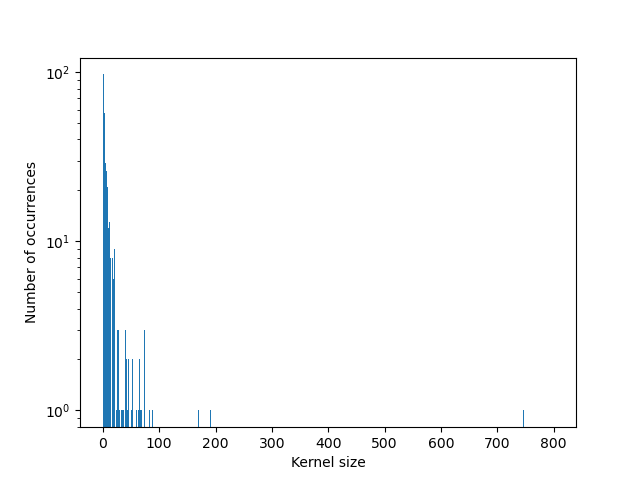

In [53]:
fig9 = plt.figure()
ax9 = fig9.add_subplot(111)
ax9.bar(xaxis[:800], kernel_sizes_upto800)#, bins = 800)#, kernel_sizes)
ax9.set_xlabel("Kernel size")
ax9.set_ylabel("Number of occurrences")
ax9.set_yscale('log')
#ax9.set_xlim(0,800)
#ax3.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

In [54]:
kernel_sizes_10 = kernel_sizes

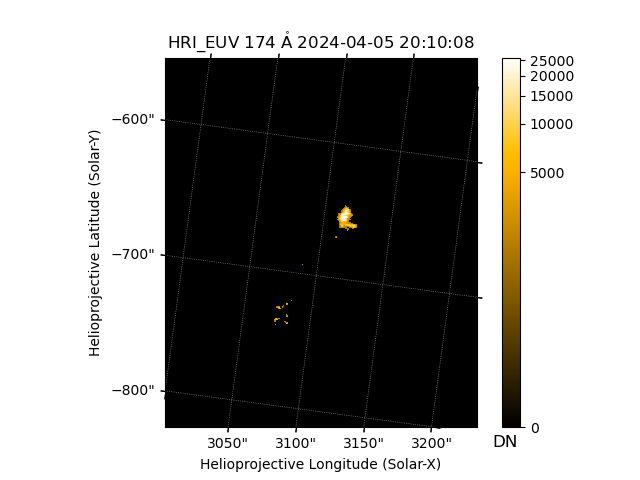

In [55]:
masked_map_seq_5[230].peek()

<h3>Running Difference</h3>

In [56]:
usable_map_seq = short_exposure_map_seq

In [57]:
map_data_list = [usable_map_seq[0].data, usable_map_seq[1].data]
for i in range(1346):
    map_data_list.append(usable_map_seq[i+2].data)

In [58]:
for i in range(1348):
    map_data_list[i] = map_data_list[i][:558, :471]

In [59]:
number_of_pixels = np.zeros(1348)
for i in range(1347):
    # if short_exposure_map_seq[i+1].dimensions[0].value != short_exposure_map_seq[i].dimensions[0].value:
    #     print(":(")
    # elif short_exposure_map_seq[i+1].dimensions[1].value != short_exposure_map_seq[i].dimensions[1].value:
    #     print(":(")
    # else:
    diff = map_data_list[i+1] - map_data_list[i]
    xdim = int(diff.shape[0])
    ydim = int(diff.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff[x,y] < 0:
                diff[x,y] = 0
            if diff[x,y] != 0:
                number_of_pixels[i+1] = number_of_pixels[i+1] + 1

Plot number of pixels that are brighter than they were in the previous frame against time

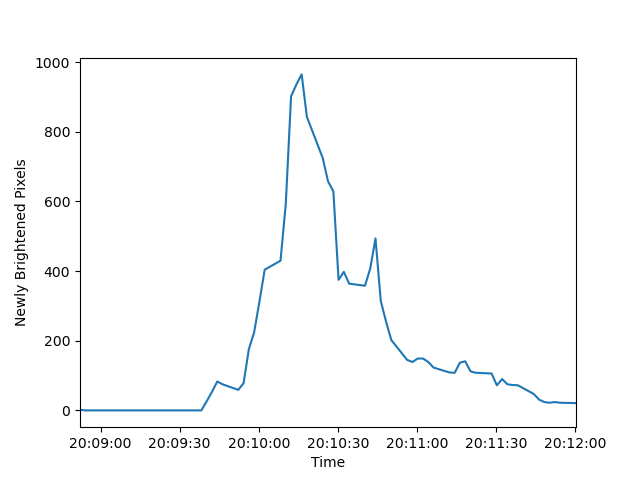

In [60]:
fig4 = plt.figure()
ax4 = fig4.add_subplot(111)
ax4.plot(euitimes.to_datetime(), number_of_pixels)
ax4.set_xlabel("Time")
ax4.set_ylabel("Newly Brightened Pixels")
ax4.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

<h3>Normalised Emission</h3>

In [61]:
normalised_emission = np.zeros(len(intensity))
for i in range(1348):
    try:
        normalised_emission[i] = intensity[i]/number_of_pixels[i]
    except:
        normalised_emission[i] = 0

C:\Users\RH\AppData\Local\Temp\ipykernel_27168\602776567.py:4: RuntimeWarning: invalid value encountered in scalar divide
  normalised_emission[i] = intensity[i]/number_of_pixels[i]
C:\Users\RH\AppData\Local\Temp\ipykernel_27168\602776567.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  normalised_emission[i] = intensity[i]/number_of_pixels[i]


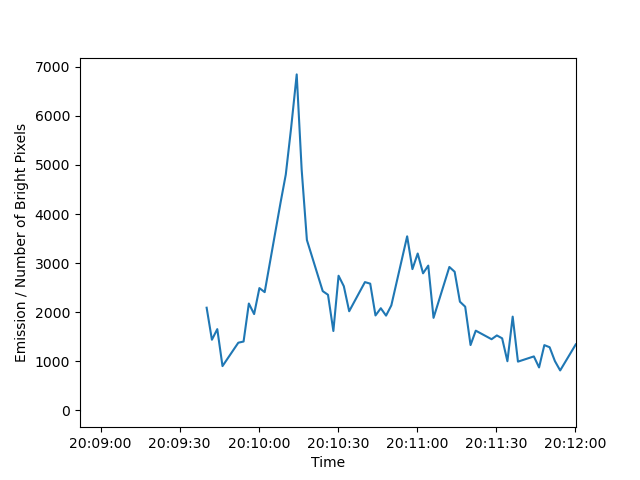

In [62]:
fig5 = plt.figure()
ax5 = fig5.add_subplot(111)
ax5.plot(euitimes.to_datetime(), normalised_emission)
ax5.set_xlabel("Time")
ax5.set_ylabel("Emission / Number of Bright Pixels")
ax5.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

<h3>Emission vs Number of Pixels</h3>

In [63]:
number_of_pixels_flare = number_of_pixels[200:270]
intensity_flare = intensity[200:270]

In [64]:
normalised_emission.argmax()

np.int64(0)

In [65]:
euitimes[200]

<Time object: scale='utc' format='isot' value=2024-04-05T20:08:52.197>

In [66]:
delt = (euitimes[230].to_datetime() - euitimes[229].to_datetime())
delt

datetime.timedelta(seconds=2)

In [67]:
time_since_flare = []
seconds_since_flare = np.zeros(70)
for i in range(41):
    time_since_flare.append(euitimes[200+i].to_datetime() - euitimes[200].to_datetime())
    seconds_since_flare[i] = time_since_flare[i].seconds

In [68]:
seconds_since_flare.max()

np.float64(108.0)

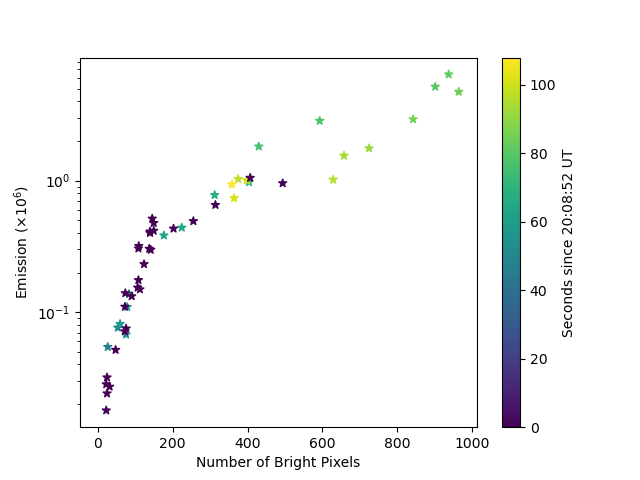

In [69]:
fig7 = plt.figure()
ax7 = fig7.add_subplot(1,1,1)

sc = ax7.scatter(number_of_pixels_flare, intensity_flare/1e6, c=seconds_since_flare, marker="*")#, vmin = 0, vmax = 7)
ax7.set_xlabel("Number of Bright Pixels")
ax7.set_ylabel(r"Emission ($\times 10^6$)")
plt.colorbar(sc,label=r'Seconds since 20:08:52 UT')
ax7.set_yscale('log')
plt.show()

<h3>Figure 5</h3>

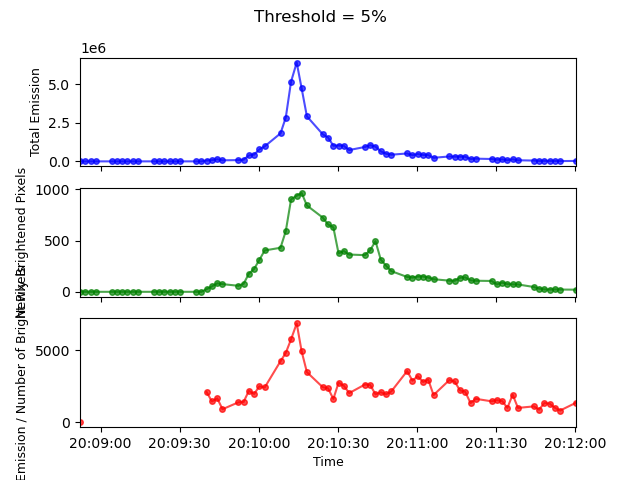

In [70]:
fig8, (axa, axb, axc) = plt.subplots(3, sharex=True)
fig8.suptitle('Threshold = 5%')

axa.plot(euitimes.to_datetime(), intensity, marker = "o", markersize = 4, linestyle = "-", color = "blue", alpha = 0.7)
axa.set_ylabel("Total Emission", fontsize = 9)

axb.plot(euitimes.to_datetime(), number_of_pixels, marker = "o", markersize = 4, linestyle = "-", color = "green", alpha = 0.7)
axb.set_ylabel("Newly Brightened Pixels", fontsize = 9)

axc.plot(euitimes.to_datetime(), normalised_emission, marker = "o", markersize = 4, linestyle = "-", color = "red", alpha = 0.7)
axc.set_ylabel("Emission / Number of Bright Pixels", fontsize = 9)

axc.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
axc.set_xlabel("Time", fontsize = 9)
plt.show()

<h3>STIX Time Profiles</h3>

In [71]:
from glob import glob
stix_data = glob(r'C:\python_code\stix_test\stix_data\*.fits')

In [72]:
spec = Product(stix_data[4])

In [73]:
spec_5_10 = np.zeros(7000)
spec_10_15 = np.zeros(7000)
spec_15_25 = np.zeros(7000)
spec_25_50 = np.zeros(7000)
spec_22_45 = np.zeros(7000)

In [74]:
for i in range(7000):
    spec_5_10[i] = (spec.data['counts'][i, 2].value + spec.data['counts'][i, 3].value 
                    + spec.data['counts'][i, 4].value + spec.data['counts'][i, 5].value + spec.data['counts'][i, 6].value)
    spec_10_15[i] = (spec.data['counts'][i, 7].value + spec.data['counts'][i, 8].value 
                    + spec.data['counts'][i, 9].value + spec.data['counts'][i, 10].value + spec.data['counts'][i, 11].value)
    spec_15_25[i] = (spec.data['counts'][i, 12].value + spec.data['counts'][i, 13].value 
                    + spec.data['counts'][i, 14].value + spec.data['counts'][i, 15].value + spec.data['counts'][i, 16].value)
    spec_25_50[i] = (spec.data['counts'][i, 17].value + spec.data['counts'][i, 18].value 
                    + spec.data['counts'][i, 19].value + spec.data['counts'][i, 20].value + spec.data['counts'][i, 21].value
                    + spec.data['counts'][i, 22].value)
    spec_22_45[i] = (spec.data['counts'][i, 16].value + spec.data['counts'][i, 17].value + spec.data['counts'][i, 18].value 
                    + spec.data['counts'][i, 19].value + spec.data['counts'][i, 20].value + spec.data['counts'][i, 21].value)

In [75]:
stix_times = spec.data['time']

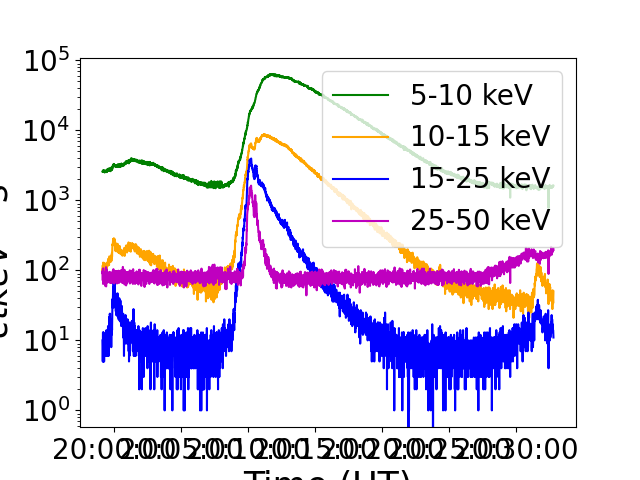

In [76]:
start = 500
end = 4300
label_size = 25
tick_size = 20
fig11 = plt.figure()#figsize = (15,8))
ax11= fig11.add_subplot(111)
ax11.plot(stix_times[start:end].to_datetime(), spec_5_10[start:end], color ='g', label = "5-10 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_10_15[start:end], color ='orange', label = "10-15 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_15_25[start:end], color ='blue', label = "15-25 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_25_50[start:end], color ='m', label = "25-50 keV")#, linestyle = 'None', marker = 'x')
ax11.set_ylabel("$ct keV^{-1} s^{-1}$", fontsize = label_size)
ax11.set_xticks([datetime(2024,4,5,20,00,0,0), datetime(2024,4,5,20,5,0,0), datetime(2024,4,5,20,10,0,0), datetime(2024,4,5,20,15,0,0), 
                 datetime(2024,4,5,20,20,0,0), datetime(2024,4,5,20,25,0,0), datetime(2024,4,5,20,30,0,0)],
               ['20:00:00', '20:05:00', '20:10:00', '20:15:00', '20:20:00', '20:25:00', '20:30:00'], fontsize = tick_size)
ax11.set_xlabel("Time (UT)", fontsize = label_size)
ax11.set_yscale('log')
#ax11.set_yticks(fontsize = 15)
for label in ax11.get_yticklabels():
    label.set_fontsize(tick_size)

ax11.legend(loc = 1, fontsize = tick_size)
plt.show()

In [77]:
euitimes[225]

<Time object: scale='utc' format='isot' value=2024-04-05T20:09:58.196>

<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:11: SyntaxWarning: invalid escape sequence '\A'
C:\Users\RH\AppData\Local\Temp\ipykernel_27168\1113120948.py:11: SyntaxWarning: invalid escape sequence '\A'
  ax13.plot(euitimes[start3:end3].to_datetime(), number_of_pixels[start3:end3], marker = "o", markersize = 6, linestyle = "-", color = "green", label = "174$\AA$ pixels", linewidth = 4)


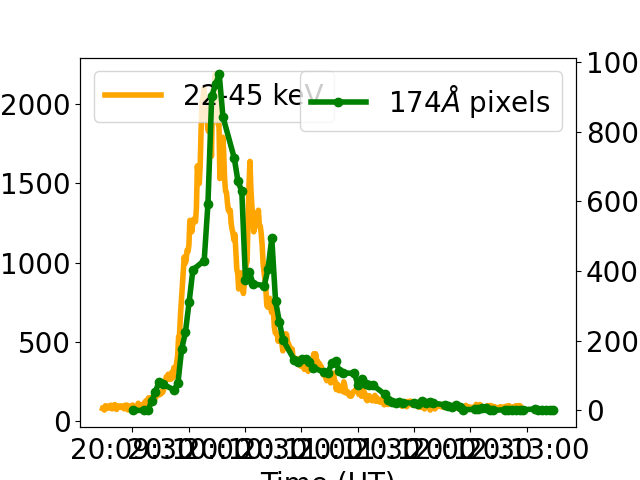

In [78]:
start2 = 1700
end2 = 2150
start3 = 215
end3 = 300
fig12 = plt.figure()#figsize = (20,7))
ax12 = fig12.add_subplot(111)
ax12.plot(stix_times[start2:end2].to_datetime(), spec_22_45[start2:end2], color ='orange', label = "22-45 keV", linewidth = 4)#, linestyle = 'None', marker = 'x')
ax12.set_ylabel("ct keV$^{-1}$ s$^{-1}$", fontsize = 20)
ax13 = ax12.twinx()

ax13.plot(euitimes[start3:end3].to_datetime(), number_of_pixels[start3:end3], marker = "o", markersize = 6, linestyle = "-", color = "green", label = "174$\AA$ pixels", linewidth = 4)
ax13.set_ylabel("Newly Brightened Pixels", fontsize = 20)
ax12.set_xlabel("Time (UT)", fontsize = 20)

for label in ax12.get_yticklabels():
    label.set_fontsize(tick_size)

for label in ax13.get_yticklabels():
    label.set_fontsize(tick_size)

for label in ax12.get_xticklabels():
    label.set_fontsize(tick_size)

ax12.legend(loc = 2, fontsize = tick_size)
ax13.legend(loc = 0, fontsize = tick_size)
plt.show()

In [79]:
start2 = 1700
end2 = 2150
start3 = 215
end3 = 300
fig14 = plt.figure()#figsize = (20,7))
ax14 = fig14.add_subplot(111)
ax14.plot(stix_times[start2:end2].to_datetime(), spec_22_45[start2:end2], color ='orange', label = "22-45 keV", linewidth = 4)#, linestyle = 'None', marker = 'x')
ax14.set_ylabel("ct keV$^{-1}$ s$^{-1}$", fontsize = 20)
ax15 = ax14.twinx()

ax15.plot(euitimes[start3:end3].to_datetime(), number_of_pixels[start3:end3]*intensity, marker = "o", markersize = 6, linestyle = "-", color = "green", label = "174$\AA$ pixels", linewidth = 4)
ax15.set_ylabel("Newly Brightened Pixels", fontsize = 20)
ax14.set_xlabel("Time (UT)", fontsize = 20)

for label in ax14.get_yticklabels():
    label.set_fontsize(tick_size)

for label in ax15.get_yticklabels():
    label.set_fontsize(tick_size)

for label in ax14.get_xticklabels():
    label.set_fontsize(tick_size)

ax14.legend(loc = 2, fontsize = tick_size)
ax15.legend(loc = 0, fontsize = tick_size)
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:11: SyntaxWarning: invalid escape sequence '\A'
C:\Users\RH\AppData\Local\Temp\ipykernel_27168\1423846412.py:11: SyntaxWarning: invalid escape sequence '\A'
  ax15.plot(euitimes[start3:end3].to_datetime(), number_of_pixels[start3:end3]*intensity, marker = "o", markersize = 6, linestyle = "-", color = "green", label = "174$\AA$ pixels", linewidth = 4)
C:\Users\RH\AppData\Local\Temp\ipykernel_27168\1423846412.py:11: SyntaxWarning: invalid escape sequence '\A'
  ax15.plot(euitimes[start3:end3].to_datetime(), number_of_pixels[start3:end3]*intensity, marker = "o", markersize = 6, linestyle = "-", color = "green", label = "174$\AA$ pixels", linewidth = 4)


ValueError: operands could not be broadcast together with shapes (85,) (1348,) 